## Jupyter notebooks for the lecture "Cosmic Structure Formation"

Winter term of 2022/23

Matthias Bartelmann, Heidelberg University

### Part (1): Cosmology

In [ ]:
from scipy.integrate import quad
from scipy.integrate import odeint
from scipy.optimize  import curve_fit
from scipy.special   import spherical_jn, wofz
from math import cos, sin, exp, log, sqrt

import numpy as np
import matplotlib.pyplot as pl

from cosmology3 import Cosmology

pl.rcParams.update ({"font.size": 9, "figure.figsize": (5,5)})

cosmology = Cosmology (omega_radiation=0)

Growth factor and time coordinate, derivative of the growth factor

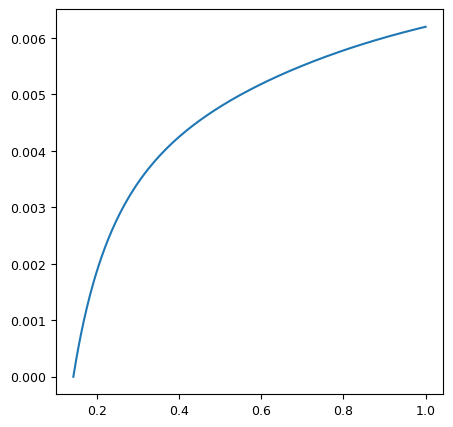

In [9]:
z = np.loadtxt("z.txt")
a = 1/(1+z)
a = a[::-1]

dpl = []
for i in a :
    dpl.append(cosmology.D_plus(i))
dpl = np.array(dpl)
dpl = dpl/dpl[0]
dplme = np.loadtxt("dpl2.txt")
dplkids = np.loadtxt("dpl_kids.txt")
dplkids = dplkids[::-1]
dplkids = dplkids/dplkids[0]
diff = (dplkids-dplme)/dplkids

pl.plot(a,diff)
# pl.plot(dpl)
# pl.plot(dplme)
# pl.plot(dplkids)
# print(diff[-1],a)

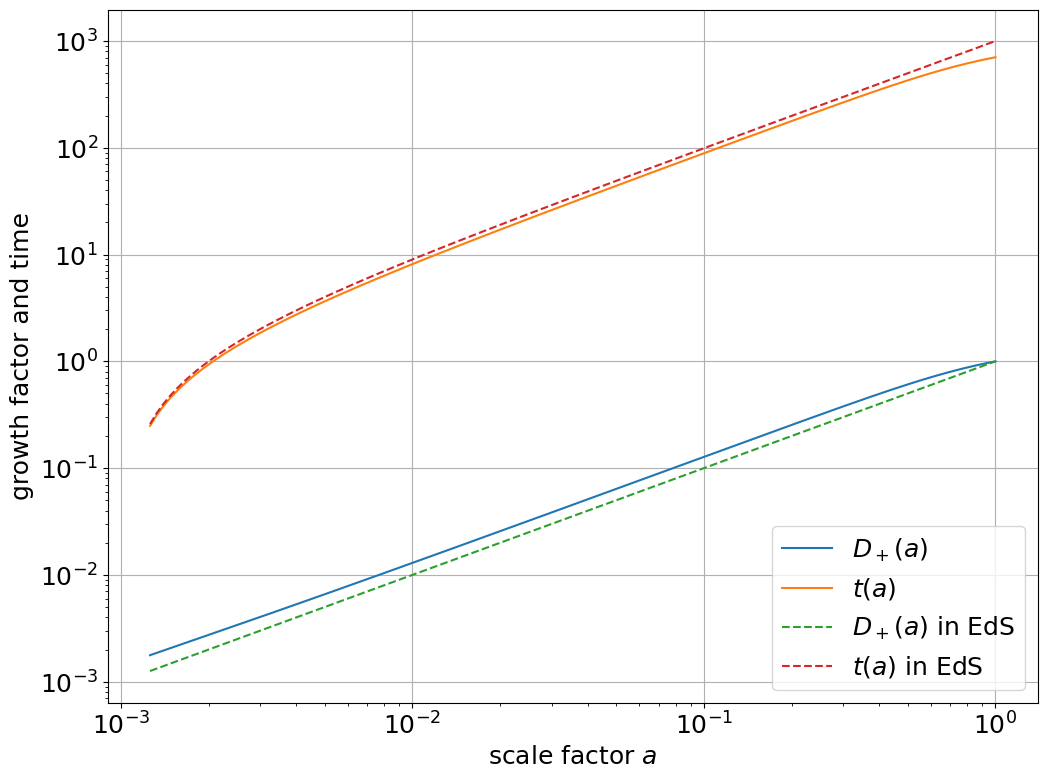

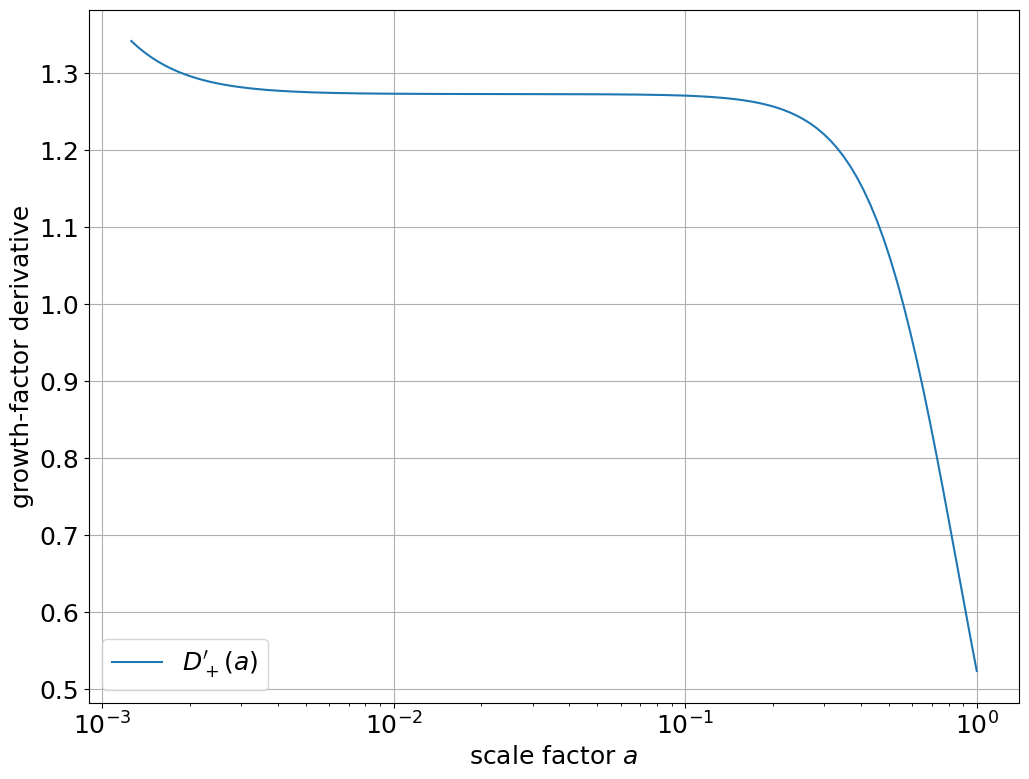

In [5]:
n = 128
x = np.logspace (-2.9, 0.0, n)

pl.plot (x, [cosmology.D_plus (v) for v in x], label = "$D_+(a)$")
pl.plot (x, [cosmology.time (v) for v in x], label = "$t(a)$")
pl.plot (x, x, "--", label = "$D_+(a)$ in EdS")
pl.plot (x, [v/cosmology.a_ini-1 for v in x], "--", label = "$t(a)$ in EdS")
pl.legend (loc = "lower right")
pl.xscale ("log")
pl.yscale ("log")
pl.xlabel ("scale factor $a$")
pl.ylabel ("growth factor and time")
pl.grid ()
pl.show ()

pl.plot (x, [cosmology.D_plus_prime (v) for v in x], label = "$D_+'(a)$")
pl.legend (loc = "lower left")
pl.xscale ("log")
pl.yscale ("linear")
pl.xlabel ("scale factor $a$")
pl.ylabel ("growth-factor derivative")
pl.grid ()
pl.show ()

Density parameters functions of the scale factor

In [ ]:
n = 256
a = np.logspace (-5.0, 0.0, n)

pl.plot (a, [cosmology.omega_radiation (v) for v in a], label = "$\\Omega_\\mathrm{r}$")
pl.plot (a, [cosmology.omega_matter (v) for v in a], label = "$\\Omega_\\mathrm{m}$")
pl.plot (a, [cosmology.omega_lambda (v) for v in a], label = "$\\Omega_\\Lambda$")
pl.legend (loc = "center left")
pl.xscale ("log")
pl.yscale ("linear")
pl.xlabel ("scale factor $a$")
pl.ylabel ("density parameters")
pl.grid ()
pl.show ()

Angular-diameter and luminosity distances

In [ ]:
n = 128
z = np.linspace (0.0, 0.25, n)

r_H = 3.0e5/70

pl.plot (z, [r_H*cosmology.angular_distance (v, 0.0) for v in z], label = "$D_\\mathrm{W}$")
pl.plot (z, [r_H*cosmology.luminosity_distance (v, 0.0) for v in z], label = "$D_\\mathrm{L}$")
pl.legend (loc = "upper left")
pl.xscale ("linear")
pl.yscale ("linear")
pl.xlabel ("redshift $z$")
pl.ylabel ("distances in Mpc")
pl.grid ()
pl.savefig ("entfernungen.pdf")
pl.show ()

Effective particle mass, Hamiltonian propagator

In [ ]:
n = 128
x = np.logspace (-3.0, 0.0, n)

pl.plot (x, [cosmology.mass (v) for v in x], label = "$m(a)$")
pl.plot (x, [(v/cosmology.a_ini)**1.5 for v in x], "--", label = "$m(a)$ in EdS")
pl.legend (loc = "lower right")
pl.xscale ("log")
pl.yscale ("log")
pl.xlabel ("scale factor $a$")
pl.ylabel ("effective particle mass")
pl.grid ()
pl.show ()

pl.plot (x, [cosmology.g_H (v) for v in x], label = "$g_\\mathrm{N}(a,a_\\mathrm{ini})$")
pl.plot (x, [2.0*(1.0-sqrt (cosmology.a_ini/v)) for v in x], "--",
         label = "$g_\\mathrm{N}(a,a_\\mathrm{ini})$ in EdS")
pl.legend (loc = "lower right")
pl.xscale ("log")
pl.yscale ("log")
pl.xlabel ("scale factor $a$")
pl.ylabel ("Hamiltonian propagator")
pl.grid ()
pl.show ()